<a href="https://colab.research.google.com/github/NehaMusale11/Machine-Vision/blob/main/MachineV_PostLab_CM23057.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install opencv-python matplotlib numpy pandas

# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("OpenCV Version:", cv2.__version__)
print("NumPy Version:", np.__version__)
print("Environment setup successful!")

OpenCV Version: 4.14.0
NumPy Version: 2.1.3
Environment setup successful!


In [2]:
!pip install -q kagglehub opencv-python matplotlib numpy pandas scikit-learn tensorflow

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow Version:", tf.__version__)
print("OpenCV Version:", cv2.__version__)
print("NumPy Version:", np.__version__)

TensorFlow Version: 2.20.0
OpenCV Version: 4.14.0
NumPy Version: 2.1.3


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [5]:
for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Number of files:", len(files))

    if len(files) > 0:
        print("Sample files:", files[:5])

    print("-" * 50)

Folder: /kaggle/input/gtsrb-german-traffic-sign
Number of files: 3
Sample files: ['Meta.csv', 'Train.csv', 'Test.csv']
--------------------------------------------------
Folder: /kaggle/input/gtsrb-german-traffic-sign/Meta
Number of files: 45
Sample files: ['37.png', '35.png', '11.png', '31.png', '4.png']
--------------------------------------------------
Folder: /kaggle/input/gtsrb-german-traffic-sign/meta
Number of files: 45
Sample files: ['37.png', '35.png', '11.png', '31.png', '4.png']
--------------------------------------------------
Folder: /kaggle/input/gtsrb-german-traffic-sign/Test
Number of files: 12631
Sample files: ['01301.png', '02578.png', '06781.png', '11396.png', '00929.png']
--------------------------------------------------
Folder: /kaggle/input/gtsrb-german-traffic-sign/test
Number of files: 12631
Sample files: ['01301.png', '02578.png', '06781.png', '11396.png', '00929.png']
--------------------------------------------------
Folder: /kaggle/input/gtsrb-german-traff

In [6]:
image_extensions = (".png", ".jpg", ".jpeg")

image_paths = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))

Total images found: 103764


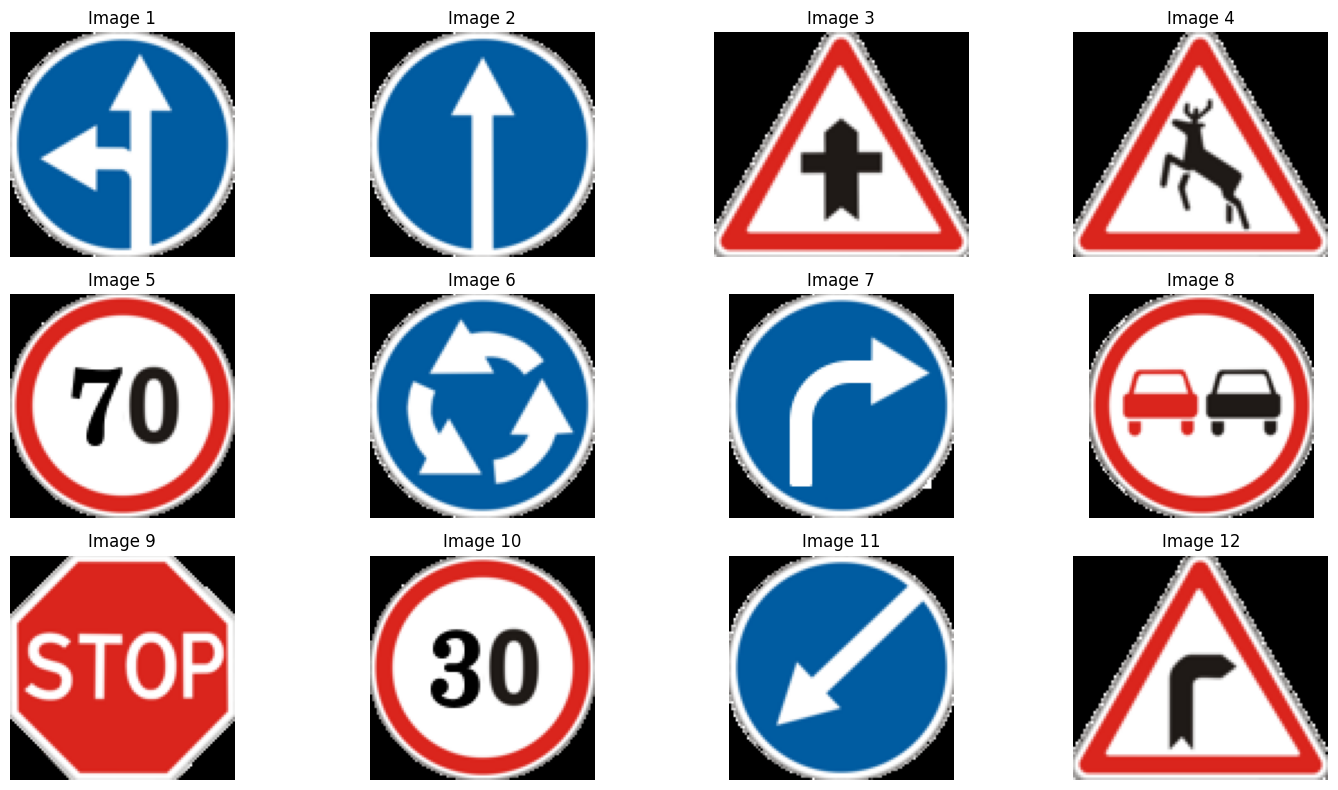

In [7]:
plt.figure(figsize=(15, 8))

for i in range(min(12, len(image_paths))):

    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
img = cv2.imread(image_paths[0])

print("Image Shape:", img.shape)
print("Height:", img.shape[0])
print("Width:", img.shape[1])
print("Channels:", img.shape[2])
print("Data Type:", img.dtype)
print("Minimum Pixel Value:", img.min())
print("Maximum Pixel Value:", img.max())

Image Shape: (100, 100, 3)
Height: 100
Width: 100
Channels: 3
Data Type: uint8
Minimum Pixel Value: 0
Maximum Pixel Value: 255


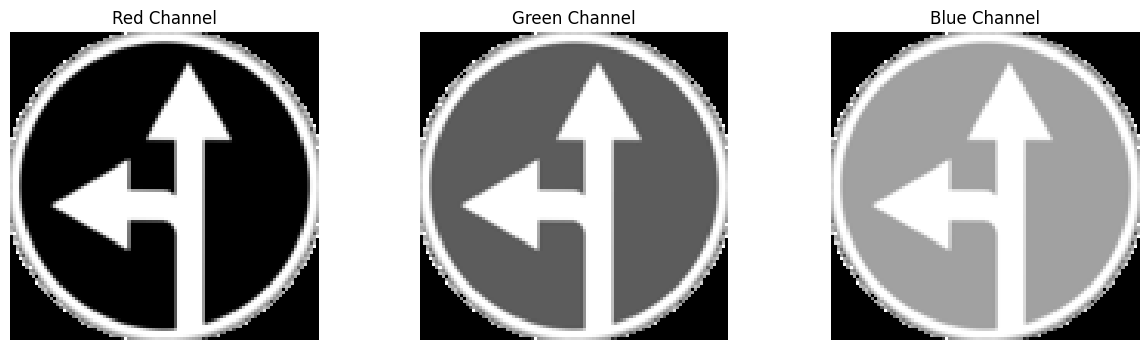

In [9]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(R, cmap="gray")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(G, cmap="gray")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(B, cmap="gray")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

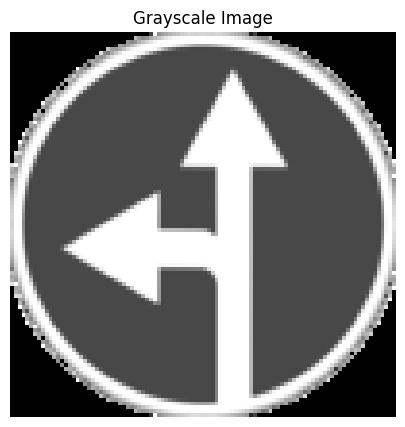

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(7, 5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

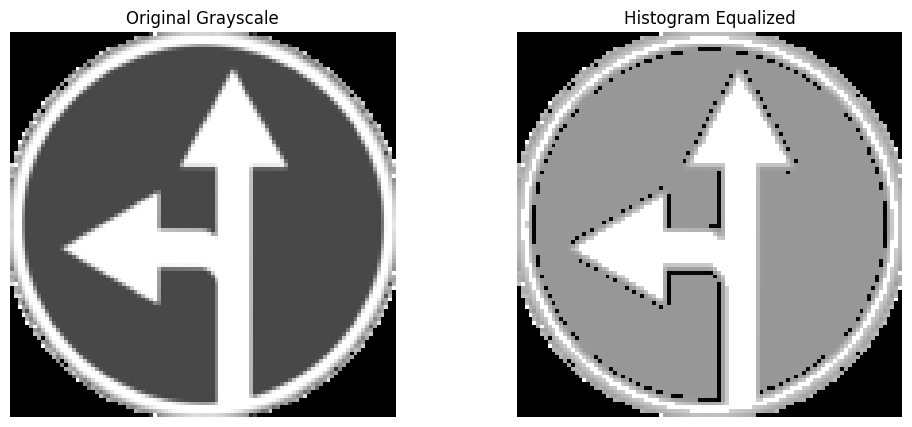

In [11]:
equalized = cv2.equalizeHist(gray)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalized")
plt.axis("off")

plt.show()

/tmp/ipykernel_1584/983707206.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0, 256])
/tmp/ipykernel_1584/983707206.py:10: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0, 256])


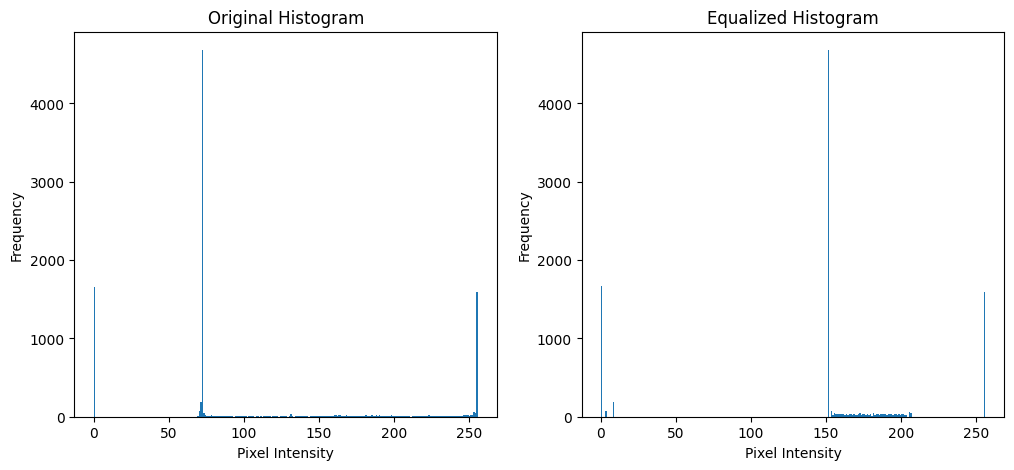

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(gray.ravel(), 256, [0, 256])
plt.title("Original Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(equalized.ravel(), 256, [0, 256])
plt.title("Equalized Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

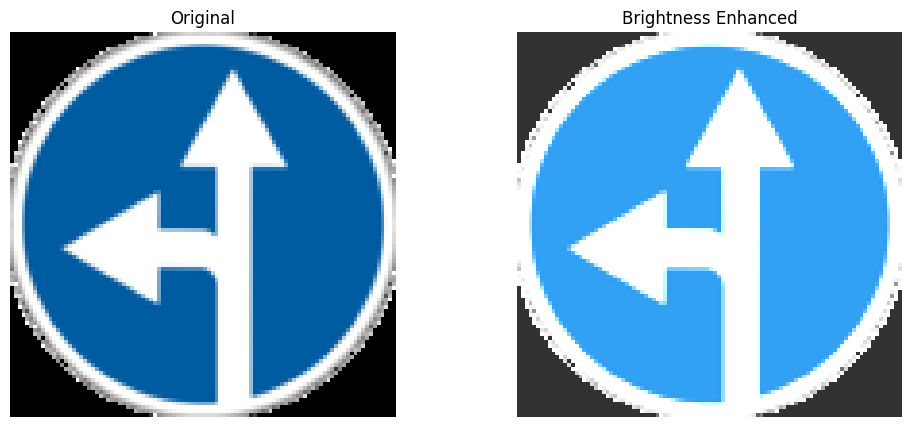

In [13]:
brightness = cv2.convertScaleAbs(
    img,
    alpha=1.2,
    beta=50
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(brightness, cv2.COLOR_BGR2RGB))
plt.title("Brightness Enhanced")
plt.axis("off")

plt.show()

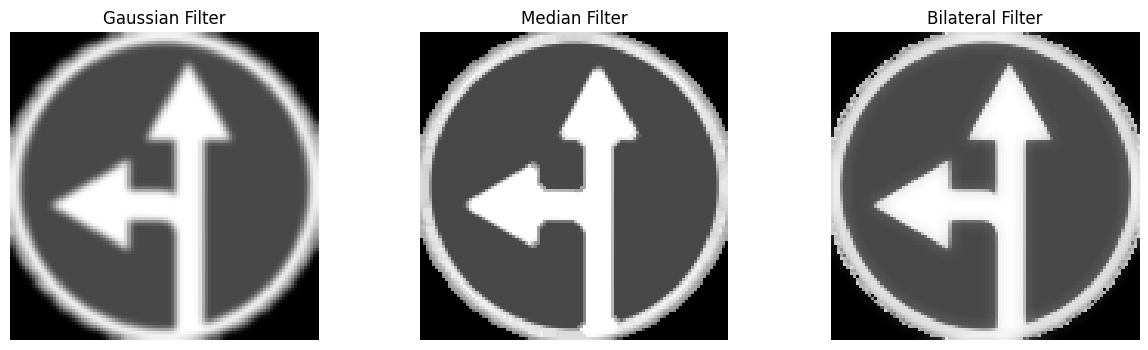

In [14]:
gaussian = cv2.GaussianBlur(gray, (5, 5), 0)

median = cv2.medianBlur(gray, 5)

bilateral = cv2.bilateralFilter(
    gray,
    9,
    75,
    75
)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bilateral, cmap="gray")
plt.title("Bilateral Filter")
plt.axis("off")

plt.show()

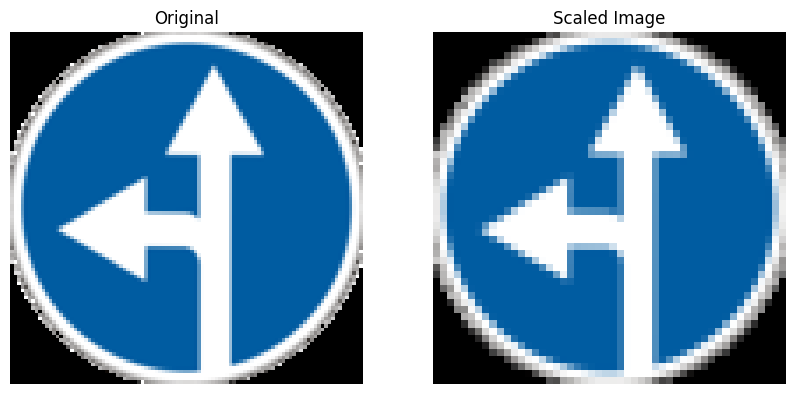

In [15]:
height, width = img.shape[:2]

scaled = cv2.resize(
    img,
    (width // 2, height // 2)
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB))
plt.title("Scaled Image")
plt.axis("off")

plt.show()

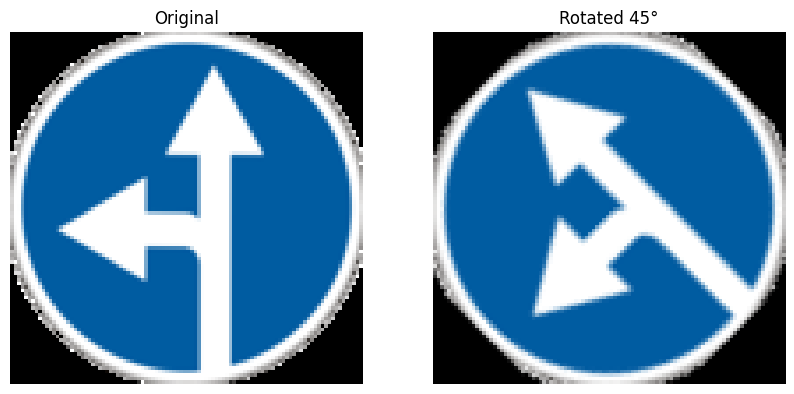

In [16]:
center = (width // 2, height // 2)

matrix = cv2.getRotationMatrix2D(
    center,
    45,
    1
)

rotated = cv2.warpAffine(
    img,
    matrix,
    (width, height)
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated 45°")
plt.axis("off")

plt.show()

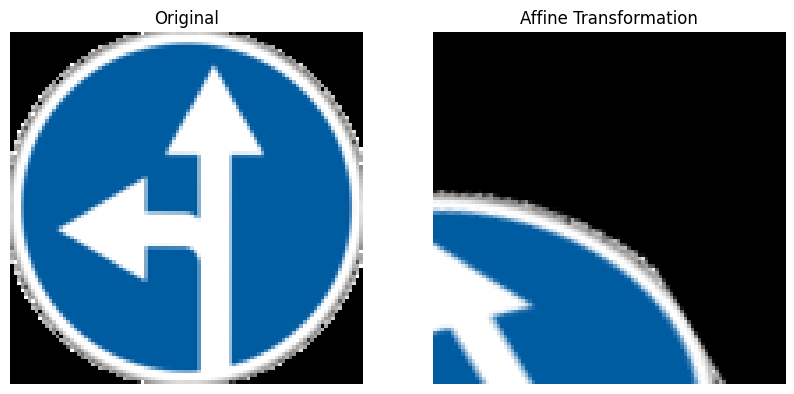

In [17]:
rows, cols = img.shape[:2]

pts1 = np.float32([
    [50, 50],
    [200, 50],
    [50, 200]
])

pts2 = np.float32([
    [10, 100],
    [200, 50],
    [100, 250]
])

affine_matrix = cv2.getAffineTransform(
    pts1,
    pts2
)

affine = cv2.warpAffine(
    img,
    affine_matrix,
    (cols, rows)
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(affine, cv2.COLOR_BGR2RGB))
plt.title("Affine Transformation")
plt.axis("off")

plt.show()

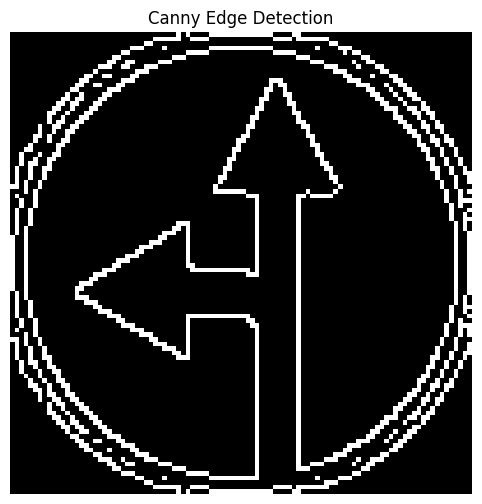

In [18]:
edges = cv2.Canny(
    gray,
    100,
    200
)

plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

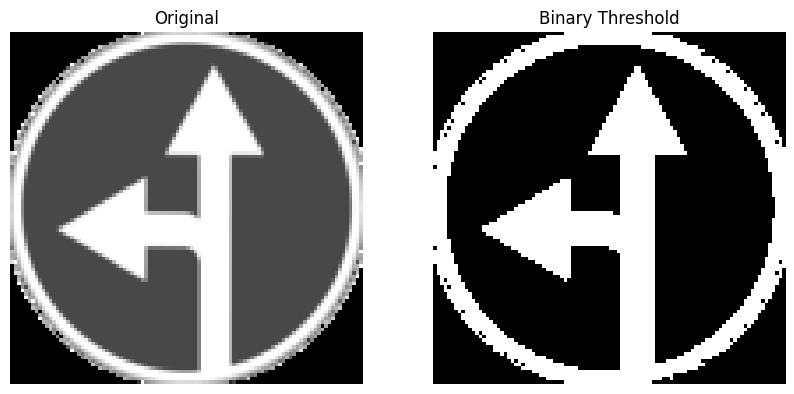

In [19]:
_, binary = cv2.threshold(
    gray,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Threshold")
plt.axis("off")

plt.show()

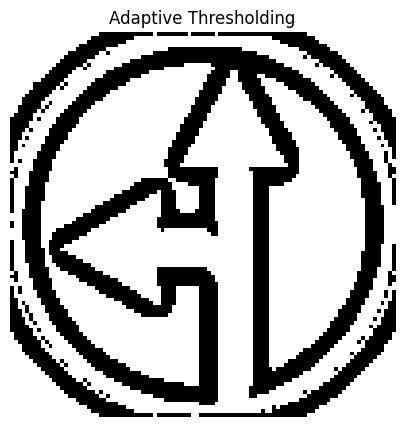

In [20]:
adaptive = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(7, 5))
plt.imshow(adaptive, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")
plt.show()

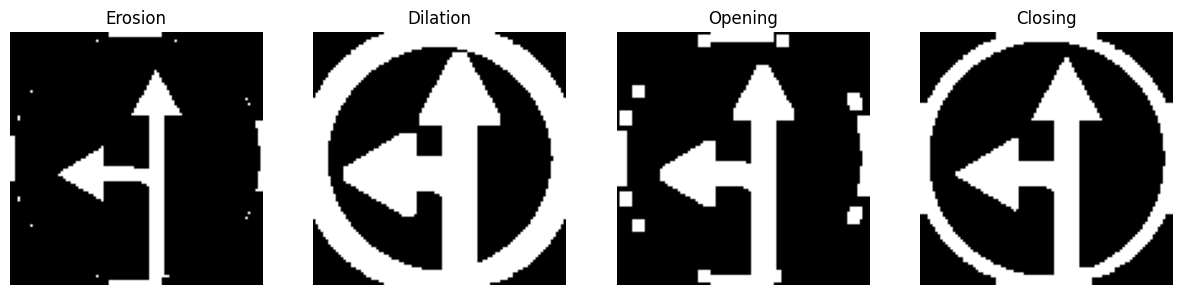

In [21]:
kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(
    binary,
    kernel,
    iterations=1
)

dilation = cv2.dilate(
    binary,
    kernel,
    iterations=1
)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

closing = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(erosion, cmap="gray")
plt.title("Erosion")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(dilation, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(opening, cmap="gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(closing, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.show()

Area: 8171.0
Width: 100
Height: 100
------------------


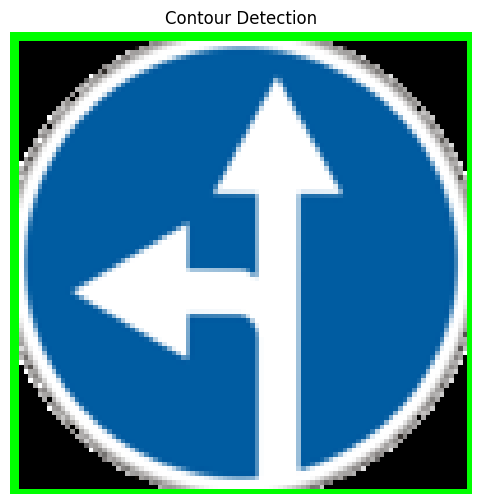

In [22]:
contours, hierarchy = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contour_img = img.copy()

for contour in contours:

    area = cv2.contourArea(contour)

    if area > 100:

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            contour_img,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        print("Area:", area)
        print("Width:", w)
        print("Height:", h)
        print("------------------")

plt.figure(figsize=(8, 6))
plt.imshow(
    cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB)
)
plt.title("Contour Detection")
plt.axis("off")
plt.show()

In [23]:
orb = cv2.ORB_create(
    nfeatures=500
)

keypoints, descriptors = orb.detectAndCompute(
    gray,
    None
)

print("Number of Keypoints:", len(keypoints))
print("Descriptor Shape:", descriptors.shape if descriptors is not None else None)

Number of Keypoints: 14
Descriptor Shape: (14, 32)


In [24]:
orb = cv2.ORB_create(
    nfeatures=500
)

keypoints, descriptors = orb.detectAndCompute(
    gray,
    None
)

print("Number of Keypoints:", len(keypoints))
print("Descriptor Shape:", descriptors.shape if descriptors is not None else None)

Number of Keypoints: 14
Descriptor Shape: (14, 32)


Number of Matches: 4


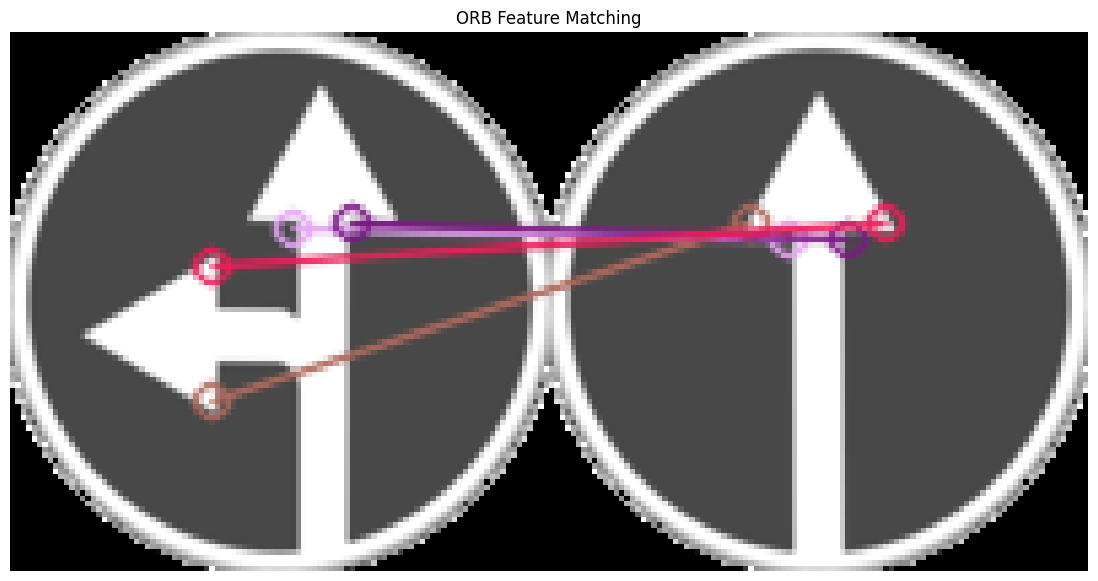

In [25]:
img1 = cv2.imread(image_paths[0], cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(image_paths[1], cv2.IMREAD_GRAYSCALE)

orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(
    cv2.NORM_HAMMING,
    crossCheck=True
)

if des1 is not None and des2 is not None:

    matches = bf.match(des1, des2)

    matches = sorted(
        matches,
        key=lambda x: x.distance
    )

    print("Number of Matches:", len(matches))

    match_img = cv2.drawMatches(
        img1,
        kp1,
        img2,
        kp2,
        matches[:30],
        None,
        flags=2
    )

    plt.figure(figsize=(15, 7))
    plt.imshow(match_img, cmap="gray")
    plt.title("ORB Feature Matching")
    plt.axis("off")
    plt.show()

else:
    print("Descriptors could not be generated.")